In [22]:
# ============================================================
# AUTOENCODER TRANSFORMER SEQ2SEQ — PYTORCH
# Migração de TensorFlow/Keras para PyTorch
# ============================================================

import os
import json
import random
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Detectar GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Device: {device}")

# ============================================================
# CONFIGURAÇÕES GLOBAIS (idênticas ao original)
# ============================================================

CONFIG = {
    "vocab_size": 72,
    "max_len": 512,
    "embed_dim": 128,
    "ff_dim": 512,
    "num_heads": 8,
    "num_layers": 4,
    "dropout_rate": 0.15,
    "batch_size": 16,
    "learning_rate": 1e-4,
    "epochs": 3,
}

# ============================================================
# DICCIONÁRIO DE EMBEDDINGS CUSTOMIZADO (sugestão do orientador)
# Mapeia caracteres ambíguos para índices fixos, evitando
# interpretação errada de tokens como 'c' (aromático vs minúsculo),
# colchetes, cargas, etc.
# ============================================================

EMBEDDING_LOOKUP = {
    # Átomos alifáticos (maiúsculos)
    'C': 1, 'N': 2, 'O': 3, 'P': 4, 'S': 5, 'F': 6, 'I': 7, 'B': 8,
    # Átomos aromáticos (minúsculos) — distinguidos dos alifáticos
    'c': 9, 'n': 10, 'o': 11, 'p': 12, 's': 13,
    # Halogênios adicionais
    'Cl': 14, 'Br': 15, 'Si': 16, 'Se': 17,
    # Ligações
    '=': 18, '#': 19, ':': 20, '-': 21, '/': 22, '\\': 23,
    # Ramificações e anéis
    '(': 24, ')': 25, '[': 26, ']': 27,
    # Numerais de anel
    '1': 28, '2': 29, '3': 30, '4': 31, '5': 32,
    '6': 33, '7': 34, '8': 35, '9': 36, '0': 37,
    # Cargas e íons
    '+': 38, '-': 39, '@': 40,
    # Separador de reagentes
    '.': 41,
    # Átomos com colchetes (frequentemente ambíguos)
    '[C@H]': 42, '[C@@H]': 43, '[C@]': 44, '[C@@]': 45,
    '[NH4+]': 46, '[Na+]': 47, '[K+]': 48, '[Cl-]': 49,
    '[Br-]': 50, '[OH-]': 51, '[O-]': 52, '[S-]': 53,
    '[N+]': 54, '[C+]': 55, '[BH4-]': 56, '[H]': 57,
    # Tokens especiais
    '<PAD>': 0,
    '<SOS>': 58,
    '<EOS>': 59,
    '<UNK>': 60,  # desconhecido
}

# Vocabulário reverso
IDX_TO_TOKEN = {v: k for k, v in EMBEDDING_LOOKUP.items()}
VOCAB_SIZE = max(EMBEDDING_LOOKUP.values()) + 1  # 61

logger.info(f"Dicionário de embeddings: {VOCAB_SIZE} tokens")
logger.info(f"Config: max_len={CONFIG['max_len']}, embed_dim={CONFIG['embed_dim']}, "
            f"ff_dim={CONFIG['ff_dim']}, heads={CONFIG['num_heads']}, layers={CONFIG['num_layers']}")

2026-09-05 02:15:54,920 - INFO - Device: cuda
2026-09-05 02:15:54,921 - INFO - Dicionário de embeddings: 61 tokens
2026-09-05 02:15:54,922 - INFO - Config: max_len=512, embed_dim=128, ff_dim=512, heads=8, layers=4


In [23]:
# ============================================================
# 2. TRANSFORMERBLOCK (PyTorch) — COM MÁSCARA CAUSAL CORRIGIDA
# ============================================================

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, is_decoder=False):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.rate = rate
        self.is_decoder = is_decoder

        self.att = nn.MultiheadAttention(embed_dim, num_heads, dropout=rate, batch_first=True)

        if self.is_decoder:
            self.cross_att = nn.MultiheadAttention(embed_dim, num_heads, dropout=rate, batch_first=True)
            self.layernorm_cross = nn.LayerNorm(embed_dim, eps=1e-6)

        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim)
        )

        self.layernorm1 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.layernorm2 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.dropout1 = nn.Dropout(rate)
        self.dropout2 = nn.Dropout(rate)

    def forward(self, x, encoder_output=None, enc_key_padding_mask=None, causal_mask=False):
        seq_len = x.size(1)

        # === MÁSCARA CAUSAL ===
        attn_mask = None
        if causal_mask:
            # triangular inferior = 1, superior = 0
            causal = torch.tril(torch.ones(seq_len, seq_len, device=x.device))
            # MultiheadAttention espera mask onde True = "mascarar" (não atender)
            attn_mask = causal == 0  # True onde NÃO pode atender (acima da diagonal)

        # === KEY PADDING MASK (ignorar PAD=0 no self-attention) ===
        # x é (batch, seq_len, embed_dim), tokens PAD têm índice 0
        key_padding_mask = None
        # extrair índices dos tokens do próprio x não é direto,
        # mas podemos passar via parâmetro se necessário

        # Self-attention
        attn_out, _ = self.att(
            x, x, x,
            attn_mask=attn_mask,
            need_weights=False
        )
        attn_out = self.dropout1(attn_out)
        out1 = self.layernorm1(x + attn_out)

        # Cross-attention (decoder only)
        if self.is_decoder and encoder_output is not None:
            cross_out, _ = self.cross_att(
                out1, encoder_output, encoder_output,
                key_padding_mask=enc_key_padding_mask,
                need_weights=False
            )
            out1 = self.layernorm_cross(out1 + cross_out)

        # Feed-forward
        ffn_out = self.ffn(out1)
        ffn_out = self.dropout2(ffn_out)
        return self.layernorm2(out1 + ffn_out)

In [24]:
# ============================================================
# 3. CARREGAMENTO DE DADOS E VOCABULÁRIO (PyTorch)
# ============================================================

def carregar_vocabulario(path="vocab_oficial.json"):
    if os.path.exists(path):
        with open(path, "r") as f:
            char_to_idx = json.load(f)
        logger.info(f"Vocabulário carregado: {len(char_to_idx)} tokens")
    else:
        raise FileNotFoundError(f"Vocabulário não encontrado em {path}. Rode o pré-processamento primeiro.")

    if '<PAD>' not in char_to_idx:
        char_to_idx['<PAD>'] = 0
    if '<SOS>' not in char_to_idx:
        char_to_idx['<SOS>'] = len(char_to_idx)
    if '<EOS>' not in char_to_idx:
        char_to_idx['<EOS>'] = len(char_to_idx)

    idx_to_char = {v: k for k, v in char_to_idx.items()}
    return char_to_idx, idx_to_char

def carregar_dados(path, n_amostras=50000):
    """Sorteia n_amostras do CSV sem carregar o arquivo inteiro na memória."""
    with open(path, 'r') as f:
        f.readline()
        total_linhas = sum(1 for _ in f)

    p = min(n_amostras / total_linhas, 1.0)
    np.random.seed(42)
    skip_mask = np.random.rand(total_linhas) > p

    def skip_fn(i):
        if i == 0:
            return False
        return skip_mask[i - 1] if (i - 1) < total_linhas else True

    df = pd.read_csv(path, skiprows=lambda i: skip_fn(i))
    all_smiles = df['input_reagentes'].dropna().astype(str).tolist()
    random.shuffle(all_smiles)

    del df
    logger.info(f"Sorteadas {len(all_smiles)} amostras de {total_linhas} linhas totais.")
    return all_smiles

def encode_seq2seq(s_list, char_to_idx, max_len):
    """Codifica para formato Seq2Seq com SOS e EOS."""
    sos = char_to_idx['<SOS>']
    eos = char_to_idx['<EOS>']

    encoder_inputs = []
    decoder_inputs = []
    targets = []

    for s in s_list:
        tokens = [char_to_idx.get(c, 0) for c in s[:max_len - 2]]

        enc = tokens + [0] * (max_len - len(tokens))
        encoder_inputs.append(enc[:max_len])

        dec = [sos] + tokens
        dec = dec + [0] * (max_len - len(dec))
        decoder_inputs.append(dec[:max_len])

        tgt = tokens + [eos]
        tgt = tgt + [0] * (max_len - len(tgt))
        targets.append(tgt[:max_len])

    return (
        np.array(encoder_inputs, dtype=np.int32),
        np.array(decoder_inputs, dtype=np.int32),
        np.array(targets, dtype=np.int32)
    )

# ============================================================
# Dataset PyTorch — substitui tf.data.Dataset
# ============================================================

class SmilesDataset(Dataset):
    """
    Dataset PyTorch para Seq2Seq.
    Equivalente ao tf.data.Dataset.from_tensor_slices + batch + prefetch.
    """
    def __init__(self, enc_inputs, dec_inputs, targets):
        self.enc = torch.LongTensor(enc_inputs)
        self.dec = torch.LongTensor(dec_inputs)
        self.tgt = torch.LongTensor(targets)

    def __len__(self):
        return len(self.enc)

    def __getitem__(self, idx):
        return self.enc[idx], self.dec[idx], self.tgt[idx]

def criar_dataloaders(enc_train, dec_train, tgt_train,
                      enc_val, dec_val, tgt_val,
                      batch_size=16):
    """Cria DataLoaders de treino e validação."""
    train_ds = SmilesDataset(enc_train, dec_train, tgt_train)
    val_ds = SmilesDataset(enc_val, dec_val, tgt_val)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=True, drop_last=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=True
    )

    return train_loader, val_loader

In [25]:
# ============================================================
# 4. FUNÇÕES DE LOSS E MÉTRICAS (PyTorch)
# ============================================================

def build_loss_weights(vocab_size, char_to_idx):
    """
    Constrói array de pesos para a loss ponderada.
    Hierarquia de penalidades (igual ao PDF seção 4):
      - PAD: 0.01x (penalidade mínima)
      - Números/ramificações/quiralidade: 5x
      - Símbolos estruturais e íons: 15x
      - Átomos reais (1 e 2 letras) + aromáticos: 20x
      - EOS: 10x (importante para parar geração)
      - SOS: 5x
    """
    weights = np.ones(vocab_size, dtype='float32')
    weights[0] = 0.01  # PAD

    # Átomos de duas letras (sugestão do orientador: juntar com os de uma letra)
    atomos = [
        # Uma letra (maiúsculas — alifáticos)
        'C', 'N', 'O', 'P', 'S', 'F', 'I', 'B', 'H',
        # Aromáticos (minúsculos — adicionados conforme sugestão)
        'c', 'n', 'o', 's', 'p',
        # Duas letras (halogênios e heteroátomos)
        'Cl', 'Br', 'Si', 'Se',
    ]
    for ch in atomos:
        if ch in char_to_idx and char_to_idx[ch] < vocab_size:
            weights[char_to_idx[ch]] = 20.0

    # Símbolos estruturais e íons
    estruturais = ['[', ']', '=', '#', ':', '.', '+', '-', '\\', '/']
    for ch in estruturais:
        if ch in char_to_idx and char_to_idx[ch] < vocab_size:
            weights[char_to_idx[ch]] = 15.0

    # Números, ramificações e quiralidade
    numeros = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '0',
               '@', '(', ')']
    for ch in numeros:
        if ch in char_to_idx and char_to_idx[ch] < vocab_size:
            weights[char_to_idx[ch]] = 5.0

    # Tokens especiais
    if '<SOS>' in char_to_idx and char_to_idx['<SOS>'] < vocab_size:
        weights[char_to_idx['<SOS>']] = 5.0
    if '<EOS>' in char_to_idx and char_to_idx['<EOS>'] < vocab_size:
        weights[char_to_idx['<EOS>']] = 10.0

    # Retorna como tensor PyTorch
    return torch.tensor(weights, dtype=torch.float32, device=device)

def weighted_masked_loss(logits, targets, loss_weights):
    """
    Loss ponderada com mascaramento de PAD.
    Equivalente ao weighted_masked_loss do Keras.

    logits: (batch, seq_len, vocab_size) — saída do modelo (PRÉ-softmax)
    targets: (batch, seq_len) — índices ground truth
    loss_weights: (vocab_size,) — pesos por token
    """
    # Flatten para (batch * seq_len,)
    batch_size, seq_len, vocab_size = logits.shape
    logits_flat = logits.view(-1, vocab_size)
    targets_flat = targets.view(-1)

    # Calcular cross-entropy sem redução (reduction='none')
    # F.cross_entropy já aplica log_softmax internamente
    loss = F.cross_entropy(logits_flat, targets_flat, weight=loss_weights,
                           reduction='none', ignore_index=0)

    # Média sobre tokens não-PAD
    mask = (targets_flat != 0).float()
    total_loss = loss.sum()
    total_tokens = mask.sum().clamp(min=1.0)

    return total_loss / total_tokens

def masked_accuracy(logits, targets):
    """
    Acurácia mascarada — ignora tokens PAD (índice 0).
    Equivalente ao masked_accuracy do Keras.
    """
    # Argmax das previsões
    preds = logits.argmax(dim=-1)  # (batch, seq_len)

    # Máscara: onde target != 0 (não é PAD)
    mask = (targets != 0).float()

    # Comparação
    correct = (preds == targets).float() * mask

    total = mask.sum().clamp(min=1.0)
    return correct.sum() / total

In [26]:
# ============================================================
# 5. MODELO SEQ2SEQ COMPLETO (PyTorch)
# ============================================================

class Seq2SeqTransformer(nn.Module):
    """
    Transformer Encoder-Decoder para SMILES.
    Equivalente direto ao build_seq2seq_model do Keras.

    Encoder: processa reagentes → representação latente
    Decoder: gera saída token a token com cross-attention no encoder
    """

    def __init__(self, vocab_size, max_len=256, embed_dim=128, ff_dim=512,
                 num_heads=8, num_layers=4, dropout=0.15):
        super().__init__()
        self.vocab_size = vocab_size
        self.max_len = max_len
        self.embed_dim = embed_dim
        self.num_layers = num_layers

        # ==================== ENCODER ====================
        # Embedding de tokens + positional encoding (soma, igual ao Keras)
        self.encoder_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.encoder_pos_emb = nn.Embedding(max_len, embed_dim)
        self.encoder_dropout = nn.Dropout(dropout)

        # 4 blocos encoder (sem cross-attention, sem máscara causal)
        self.encoder_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_dim, rate=dropout, is_decoder=False)
            for _ in range(num_layers)
        ])

        # ==================== DECODER ====================
        self.decoder_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.decoder_pos_emb = nn.Embedding(max_len, embed_dim)
        self.decoder_dropout = nn.Dropout(dropout)

        # 4 blocos decoder (com cross-attention + máscara causal)
        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_dim, rate=dropout, is_decoder=True)
            for _ in range(num_layers)
        ])

        # Camada de saída — retorna LOGITS (sem softmax)
        # F.cross_entropy aplica log_softmax internamente
        self.output_dense = nn.Linear(embed_dim, vocab_size)

    def encode(self, enc_input):
        """
        Encoder: processa reagentes.
        enc_input: (batch, seq_len) — índices dos tokens
        retorna: (batch, seq_len, embed_dim) — representação latente
        """
        batch_size = enc_input.size(0)
        seq_len = enc_input.size(1)

        # Token embeddings
        x = self.encoder_emb(enc_input)  # (batch, seq_len, embed_dim)

        # Positional encoding (soma, igual ao Keras)
        positions = torch.arange(seq_len, device=enc_input.device).unsqueeze(0)  # (1, seq_len)
        x = x + self.encoder_pos_emb(positions)

        x = self.encoder_dropout(x)

        # Passar pelos blocos encoder
        for block in self.encoder_blocks:
            x = block(x, causal_mask=False)

        return x  # encoder_output

    def decode(self, dec_input, encoder_output):
        batch_size = dec_input.size(0)
        seq_len = dec_input.size(1)

        x = self.decoder_emb(dec_input)
        positions = torch.arange(seq_len, device=dec_input.device).unsqueeze(0)
        x = x + self.decoder_pos_emb(positions)
        x = self.decoder_dropout(x)

        # Máscara de PAD do encoder (para cross-attention ignorar PADs)
        enc_padding_mask = (encoder_output.sum(dim=-1) == 0)  # (batch, seq_len) — True onde é PAD

        for block in self.decoder_blocks:
            x = block(x, encoder_output=encoder_output,
                      enc_key_padding_mask=enc_padding_mask, causal_mask=True)

        logits = self.output_dense(x)
        return logits
    def forward(self, enc_input, dec_input):
        """
        Forward completo: encoder → decoder → logits.
        enc_input: (batch, seq_len) — reagentes
        dec_input: (batch, seq_len) — <SOS> + tokens (teacher forcing)
        retorna: (batch, seq_len, vocab_size) — logits
        """
        encoder_output = self.encode(enc_input)
        logits = self.decode(dec_input, encoder_output)
        return logits

def build_model(vocab_size, config):
    """
    Factory function — equivalente ao build_seq2seq_model do Keras.
    """
    model = Seq2SeqTransformer(
        vocab_size=vocab_size,
        max_len=config["max_len"],
        embed_dim=config["embed_dim"],
        ff_dim=config["ff_dim"],
        num_heads=config["num_heads"],
        num_layers=config["num_layers"],
        dropout=config["dropout_rate"],
    )
    model = model.to(device)
    return model

In [33]:
# ============================================================
# 6. SALVAMENTO E CARREGAMENTO (PyTorch)
# ============================================================

def salvar_modelo(model, path="molgpt_autoencoder_weights.pt"):
    """
    Salva apenas os pesos (state_dict).
    Para carregar, basta reconstruir a arquitetura do código
    e chamar load_state_dict. Nunca falha entre sessões.
    """
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': CONFIG,
        'vocab_size': model.vocab_size,
    }, path)
    logger.info(f"Pesos salvos em {path}")

def carregar_modelo(path="molgpt_autoencoder_weights.pt",
                    char_to_idx=None):
    """
    Reconstrói a arquitetura do código e carrega os pesos.
    Precisa do char_to_idx para calcular vocab_size.
    """
    checkpoint = torch.load(path, map_location=device, weights_only=True)

    # Usar config salva ou a global
    config = checkpoint.get('config', CONFIG)
    vocab_size = checkpoint.get('vocab_size', len(char_to_idx))

    # Reconstruir arquitetura
    model = build_model(vocab_size, config)

    # Carregar pesos
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    logger.info(f"Pesos carregados de {path} | vocab_size={vocab_size}")
    return model
def carregar_modelo2(path="molgpt_autoencoder_weights.pt", char_to_idx=None):
    """
    Reconstrói a arquitetura e carrega os pesos.
    Detecta automaticamente se o .pt é state_dict puro
    ou dicionário wrapper com 'model_state_dict'.
    """
    checkpoint = torch.load(path, map_location=device, weights_only=True)

    # Detectar formato
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        # Formato wrapper (salvar_modelo / salvar_checkpoint_epoca)
        config = checkpoint.get('config', CONFIG)
        vocab_size = checkpoint.get('vocab_size', len(char_to_idx))
        state_dict = checkpoint['model_state_dict']
    else:
        # State_dict puro (torch.save(model.state_dict(), path))
        config = CONFIG
        vocab_size = len(char_to_idx)
        state_dict = checkpoint

    model = build_model(vocab_size, config)
    model.load_state_dict(state_dict)
    model.eval()

    logger.info(f"Pesos carregados de {path} | vocab_size={vocab_size} | formato: {'wrapper' if 'model_state_dict' in checkpoint if isinstance(checkpoint, dict) else 'state_dict puro'}")
    return model
def salvar_vocabulario(char_to_idx, path="vocab_oficial.json"):
    """
    Salva vocabulário em JSON (igual ao TensorFlow).
    """
    with open(path, "w") as f:
        json.dump(char_to_idx, f)
    logger.info(f"Vocabulário salvo em {path}")

def salvar_checkpoint_epoca(model, optimizer, epoch, path=None):
    """
    Salva checkpoint completo por época (modelo + otimizador + época).
    Permite retomar o treino exatamente de onde parou.
    """
    if path is None:
        path = f"molgpt_ep{epoch:02d}.pt"

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'config': CONFIG,
        'vocab_size': model.vocab_size,
    }, path)
    logger.info(f"Checkpoint época {epoch} salvo em {path}")

def carregar_checkpoint(path, model, optimizer=None):
    """
    Carrega checkpoint de época específica.
    Retorna a época para continuar o treino de onde parou.
    """
    checkpoint = torch.load(path, map_location=device, weights_only=True)

    model.load_state_dict(checkpoint['model_state_dict'])

    if optimizer is not None and 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    epoch = checkpoint.get('epoch', 0)
    logger.info(f"Checkpoint carregado de {path} | época {epoch}")
    return epoch

SyntaxError: expected 'else' after 'if' expression (1259621305.py, line 63)

In [28]:
# ============================================================
# 7. FUNÇÃO DE INFERÊNCIA AUTOREGRESSIVA (PyTorch)
# ============================================================

def inferencia_autoregressiva(model, smiles_input, char_to_idx, idx_to_char, max_len=256):
    """
    Codifica uma SMILES de entrada e gera a reconstrução
    token a token via inferência autoregressiva.
    """
    model.eval()
    sos = char_to_idx['<SOS>']
    eos = char_to_idx['<EOS>']

    # 1. Codificar entrada
    enc_input = [char_to_idx.get(c, 0) for c in smiles_input[:max_len]]
    enc_input = enc_input + [0] * (max_len - len(enc_input))
    enc_input = torch.LongTensor([enc_input]).to(device)

    # 2. Iniciar decoder com SOS
    dec_input = torch.LongTensor([[sos] + [0] * (max_len - 1)]).to(device)

    # 3. Geração autoregressiva
    resultado = []
    with torch.no_grad():
        for t in range(max_len - 1):
            logits = model(enc_input, dec_input)
            next_token = logits[0, t].argmax().item()

            if next_token == eos:
                break
            if next_token == 0:  # PAD
                continue

            resultado.append(idx_to_char.get(next_token, '?'))
            dec_input[0, t + 1] = next_token

    return ''.join(resultado)

def avaliar_reconstrucao(model, smiles_list, char_to_idx, idx_to_char, n_amostras=20):
    """Avalia taxa de reconstrução exata em n_amostras."""
    sucessos = 0
    for i, smi in enumerate(smiles_list[:n_amostras]):
        recon = inferencia_autoregressiva(model, smi, char_to_idx, idx_to_char)
        match = "OK" if recon == smi else "FAIL"
        if recon == smi:
            sucessos += 1
        if i < 5:
            logger.info(f"  [{match}] Original: {smi[:50]} | Recon: {recon[:50]}")

    taxa = sucessos / n_amostras * 100
    logger.info(f"Taxa de reconstrução exata: {sucessos}/{n_amostras} ({taxa:.1f}%)")
    return taxa

In [29]:
# ============================================================
# 8. PIPELINE DE TREINAMENTO COMPLETO (PyTorch)
# ============================================================

def treinar_autoencoder(dataset_path, n_amostras=200000):
    config = CONFIG.copy()

    # 1. Carregar vocabulário e dados
    char_to_idx, idx_to_char = carregar_vocabulario("vocab_oficial.json")
    vocab_size = max(len(char_to_idx), config["vocab_size"])
    config["vocab_size"] = vocab_size

    all_smiles = carregar_dados(dataset_path, n_amostras)
    n_train = int(len(all_smiles) * 0.9)
    train_smiles = all_smiles[:n_train]
    val_smiles = all_smiles[n_train:]

    logger.info(f"Codificando {len(train_smiles)} treino + {len(val_smiles)} val...")
    enc_train, dec_train, tgt_train = encode_seq2seq(train_smiles, char_to_idx, config["max_len"])
    enc_val, dec_val, tgt_val = encode_seq2seq(val_smiles, char_to_idx, config["max_len"])

    # 2. Criar DataLoaders
    train_loader, val_loader = criar_dataloaders(
        enc_train, dec_train, tgt_train,
        enc_val, dec_val, tgt_val,
        batch_size=config["batch_size"]
    )

    # 3. Construir modelo
    model = build_model(vocab_size, config)
    logger.info(f"Modelo: {sum(p.numel() for p in model.parameters()):,} parâmetros")

    # 4. Loss, otimizador e scheduler
    loss_weights = build_loss_weights(vocab_size, char_to_idx)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=config["learning_rate"]
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6
    )

    # 5. Loop de treinamento
    best_val_loss = float('inf')
    patience_counter = 0
    patience = 3
    history = {'loss': [], 'val_loss': [], 'masked_accuracy': [], 'val_masked_accuracy': []}

    logger.info("Iniciando treinamento...")

    for epoch in range(1, config["epochs"] + 1):
        # --- TREINO ---
        model.train()
        epoch_loss = 0.0
        epoch_acc = 0.0
        n_batches = 0

        for batch_idx, (enc_batch, dec_batch, tgt_batch) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch} Treino", leave=False)):
            enc_batch = enc_batch.to(device)
            dec_batch = dec_batch.to(device)
            tgt_batch = tgt_batch.to(device)

            optimizer.zero_grad()

            # Forward — retorna logits (sem softmax)
            logits = model(enc_batch, dec_batch)

            # Loss ponderada
            loss = weighted_masked_loss(logits, tgt_batch, loss_weights)

            # Backward
            loss.backward()

            # Gradient clipping (equivalente ao clipnorm=1.0 do Keras)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            # Métricas
            acc = masked_accuracy(logits, tgt_batch)
            epoch_loss += loss.item()
            epoch_acc += acc.item()
            n_batches += 1

            if batch_idx % 100 == 0:
                logger.info(f"  Epoch {epoch} | Batch {batch_idx}/{len(train_loader)} | "
                           f"Loss: {loss.item():.4f} | Acc: {acc.item():.4f}")

        train_loss = epoch_loss / n_batches
        train_acc = epoch_acc / n_batches

        # --- VALIDAÇÃO ---
        model.eval()
        val_loss = 0.0
        val_acc = 0.0
        n_val_batches = 0

        with torch.no_grad():
            for enc_batch, dec_batch, tgt_batch in tqdm(val_loader, desc=f"Epoch {epoch} Val", leave=False):
                enc_batch = enc_batch.to(device)
                dec_batch = dec_batch.to(device)
                tgt_batch = tgt_batch.to(device)

                logits = model(enc_batch, dec_batch)
                loss = weighted_masked_loss(logits, tgt_batch, loss_weights)
                acc = masked_accuracy(logits, tgt_batch)

                val_loss += loss.item()
                val_acc += acc.item()
                n_val_batches += 1

        val_loss /= n_val_batches
        val_acc /= n_val_batches

        # Scheduler
        scheduler.step(val_loss)

        # Histórico
        history['loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['masked_accuracy'].append(train_acc)
        history['val_masked_accuracy'].append(val_acc)

        logger.info(f"Epoch {epoch}/{config['epochs']} | "
                   f"Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | "
                   f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
                   f"LR: {optimizer.param_groups[0]['lr']:.2e}")

        # --- CHECKPOINT POR ÉPOCA ---
        salvar_checkpoint_epoca(model, optimizer, epoch)

        # --- EARLY STOPPING ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Salvar melhor modelo
            salvar_modelo(model, "molgpt_autoencoder_best.pt")
            logger.info(f"  ★ Novo melhor modelo! Val loss: {val_loss:.4f}")
        else:
            patience_counter += 1
            logger.info(f"  Patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                logger.info("Early stopping ativado!")
                break

    # 6. Salvar modelo final
    salvar_modelo(model, "molgpt_autoencoder_final.pt")
    salvar_vocabulario(char_to_idx)

    # 7. Testar reconstrução
    logger.info("Testando reconstrução...")
    taxa = avaliar_reconstrucao(model, val_smiles[:20], char_to_idx, idx_to_char)

        # Salvar histórico em CSV
    df_hist = pd.DataFrame(history)
    df_hist.index = range(1, len(df_hist) + 1)
    df_hist.index.name = 'epoch'
    df_hist.to_csv("training_history.csv")
    logger.info("Histórico salvo em training_history.csv")

    return model, history, char_to_idx, idx_to_char

def plotar_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history['masked_accuracy'], label='Treino', color='blue')
    ax1.plot(history['val_masked_accuracy'], label='Validação', color='orange')
    ax1.set_title('Acurácia Mascarada')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Acurácia')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history['loss'], label='Treino', color='blue')
    ax2.plot(history['val_loss'], label='Validação', color='orange')
    ax2.set_title('Loss Ponderada')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig("training_history.png", dpi=400)
    plt.show()
    logger.info("Histórico salvo em training_history.png")

In [30]:
def criar_vocabulario(dataset_path, n_amostras=200000, output_path="vocab_oficial.json"):
    """Cria vocabulário a partir do dataset."""
    with open(dataset_path, 'r') as f:
        f.readline()
        total_linhas = sum(1 for _ in f)

    p = min(n_amostras / total_linhas, 1.0)
    np.random.seed(42)
    skip_mask = np.random.rand(total_linhas) > p

    def skip_fn(i):
        if i == 0:
            return False
        return skip_mask[i - 1] if (i - 1) < total_linhas else True

    df = pd.read_csv(dataset_path, skiprows=lambda i: skip_fn(i))
    all_smiles = df['input_reagentes'].dropna().astype(str).tolist()
    del df

    vocab = sorted(list(set("".join(all_smiles))))
    char_to_idx = {ch: i + 1 for i, ch in enumerate(vocab)}
    char_to_idx['<PAD>'] = 0
    char_to_idx['<SOS>'] = len(char_to_idx)
    char_to_idx['<EOS>'] = len(char_to_idx)

    with open(output_path, "w") as f:
        json.dump(char_to_idx, f)

    logger.info(f"Vocabulário criado: {len(char_to_idx)} tokens. Salvo em {output_path}")
    return char_to_idx

In [10]:
# ============================================================
# 9. EXECUÇÃO PRINCIPAL (PyTorch)
# ============================================================

# 1. Criar vocabulário (se não existir)
if not os.path.exists("vocab_oficial.json"):
    logger.info("Criando vocabulário...")
    criar_vocabulario("/kaggle/input/datasets/glaucosoares/dados-reacoes/dados_reacoes.csv", n_amostras=200000)


In [11]:
# 2. Treinar autoencoder
model, history, char_to_idx, idx_to_char = treinar_autoencoder(
    dataset_path="/kaggle/input/datasets/glaucosoares/dados-reacoes/dados_reacoes.csv",
    n_amostras=200000
)


2026-09-04 18:36:14,766 - INFO - Vocabulário carregado: 67 tokens
2026-09-04 18:36:16,753 - INFO - Sorteadas 199137 amostras de 1351086 linhas totais.
2026-09-04 18:36:16,755 - INFO - Codificando 179223 treino + 19914 val...
2026-09-04 18:36:40,839 - INFO - Modelo: 2,010,184 parâmetros
2026-09-04 18:36:41,698 - INFO - Iniciando treinamento...
Epoch 1 Treino: 100%|█████████▉| 11200/11201 [35:04<00:00,  5.28it/s]2026-09-04 19:11:46,595 - INFO -   Epoch 1 | Batch 11200/11201 | Loss: 0.2321 | Acc: 0.9914
2026-09-04 19:12:53,268 - INFO - Epoch 1/3 | Loss: 9.3685 | Acc: 0.7331 | Val Loss: 0.3905 | Val Acc: 0.9849 | LR: 1.00e-04
2026-09-04 19:12:53,372 - INFO - Checkpoint época 1 salvo em molgpt_ep01.pt
2026-09-04 19:12:53,392 - INFO - Pesos salvos em molgpt_autoencoder_best.pt
2026-09-04 19:12:53,393 - INFO -   ★ Novo melhor modelo! Val loss: 0.3905
Epoch 2 Treino: 100%|█████████▉| 11200/11201 [35:06<00:00,  5.29it/s]2026-09-04 19:48:00,409 - INFO -   Epoch 2 | Batch 11200/11201 | Loss: 0.15

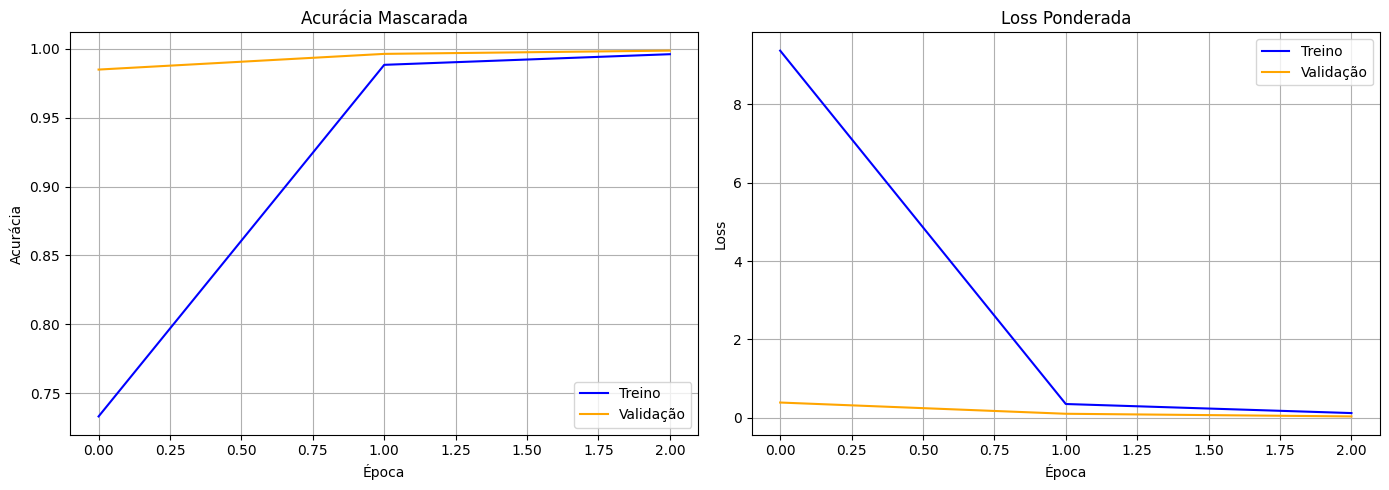

2026-09-04 20:25:25,932 - INFO - Histórico salvo em training_history.png


In [12]:


# 3. Plotar histórico
plotar_history(history)



In [36]:
# !pip install rdkit
model = ''
# 4. Teste rápido com moléculas do dataset
from rdkit import Chem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

logger.info("\n" + "=" * 60)
logger.info("TESTE DE RECONSTRUÇÃO")
logger.info("=" * 60)

# Pegar 5 amostras reais do dataset
df_teste = pd.read_csv("/kaggle/input/datasets/glaucosoares/dados-reacoes/dados_reacoes.csv", nrows=50)
# reais = df_teste['input_reagentes'].dropna().astype(str).sample(5, random_state=113).tolist()
reais = df_teste['input_reagentes'].dropna().astype(str).sample(30).tolist()
reais.append("CCO")
reais.append("CC(=O)Oc1ccccc1C(=O)O")
reais.append("CC(=O)Nc1ccc(O)cc1")
reais.append("Cn1cnc2c1c(=O)n(C)c(=O)n2C")
reais.append("CC(C)Cc1ccc(C(C)C(=O)O)cc1")
reais.append("CN1CCCC1c2cccnc2")
reais.append("CN(C)C(=N)N=C(N)N")
reais.append("Clc1cccc2ccccc12")
reais.append("NCCc1ccc(O)c(O)c1")
reais.append("CNCCC(Oc1ccc(C(F)(F)F)cc1)c2ccccc2")

# 5. Recarregar modelo salvo
char_to_idx, idx_to_char = carregar_vocabulario("/kaggle/input/datasets/glaucosoares/vocab-oficial-json/vocab_oficial.json")
model = carregar_modelo("/kaggle/input/models/glaucosoares/molgpt-ep03-pt/pytorch/default/1/molgpt_ep03.pt", char_to_idx=char_to_idx)
model.eval()

for i, smi in enumerate(reais):
    recon = inferencia_autoregressiva(model, smi, char_to_idx, idx_to_char)
    mol_out = Chem.MolFromSmiles(recon)
    valid = "válida" if mol_out else "INVÁLIDA"
    match = "EXATO" if recon == smi else "DIFERENTE"

    # Comparação canônica
    canon = ""
    mol_in = Chem.MolFromSmiles(smi)
    if mol_in and mol_out:
        if Chem.MolToSmiles(mol_in) == Chem.MolToSmiles(mol_out):
            canon = " | MESMA molécula"
        else:
            canon = " | molécula diferente"

    print(f"[{i+1}] Orig:  {smi}")
    print(f"    Rec:   {recon}")
    print(f"    {match} | {valid}{canon}")
    print("-" * 40)

# 5. Para recarregar o modelo depois (exemplo):
# model = carregar_modelo("molgpt_autoencoder_final.pt", char_to_idx=char_to_idx)
# model.eval()
# recon = inferencia_autoregressiva(model, "CCO", char_to_idx, idx_to_char)

2026-09-05 02:25:48,034 - INFO - 
2026-09-05 02:25:48,036 - INFO - TESTE DE RECONSTRUÇÃO
2026-09-05 02:25:48,036 - INFO - ============================================================
2026-09-05 02:25:48,049 - INFO - Vocabulário carregado: 67 tokens
2026-09-05 02:25:48,512 - INFO - Pesos carregados de /kaggle/input/models/glaucosoares/molgpt-ep03-pt/pytorch/default/1/molgpt_ep03.pt | vocab_size=72


[1] Orig:  [C-]#[N+][C@H]1C(=O)N2[C@@H]1CCOC2(C)C.CCC[CH2][SnH]([CH2]CCC)[CH2]CCC.CC(C)(C#N)N=NC(C)(C)C#N.c1ccccc1
    Rec:   [C-]#[N+][C@H]1C(=O)N2[C@@H]1CCOC2(C)C.CCC[CH2][SnH]([CH2]CCC)[CH2]CCC.CC(C)(C#N)N=NC(C)(C)C#N.c1ccccc1
    EXATO | válida | MESMA molécula
----------------------------------------
[2] Orig:  NCC(O)c1cccc(Cl)c1.COC(=O)c1ccc(OCC(C)=O)cc1C(=O)OC.c1ccccc1.[BH4-].[Na+].CO
    Rec:   NCC(O)c1cccc(Cl)c1.COC(=O)c1ccc(OCC(C)=O)cc1C(=O)OC.c1ccccc1.[BH4-].[Na+].CO
    EXATO | válida | MESMA molécula
----------------------------------------
[3] Orig:  CC1CCCC(=O)C1.Cn1cc([N+](=O)[O-])cc([N+](=O)[O-])c1=O.N
    Rec:   CC1CCCC(=O)C1.Cn1cc([N+](=O)[O-])cc([N+](=O)[O-])c1=O.N
    EXATO | válida | MESMA molécula
----------------------------------------
[4] Orig:  C#CCOCCCS(=O)(=O)[O-].[Na+].O=S(Cl)Cl.ClCCl
    Rec:   C#CCOCCCS(=O)(=O)[O-].[Na+].O=S(Cl)Cl.ClCCl
    EXATO | válida | MESMA molécula
----------------------------------------
[5] Orig:  [N-]=[N+]=[N-].[Na+].O=S(=O)(O)

In [14]:

 torch.save(model.state_dict(), "molgpt_autoencoder_final.pt")

In [15]:
# ============================================================
# TESTE RÁPIDO — SALVAR, CARREGAR E INFERIR
# ============================================================

# 1. Criar modelo dummy
char_to_idx, idx_to_char = carregar_vocabulario("vocab_oficial.json")
vocab_size = max(len(char_to_idx), 72)
model_teste = build_model(vocab_size, CONFIG)
model_teste.eval()

# 2. Inferência ANTES de salvar
smi_teste = "CCO"
recon_antes = inferencia_autoregressiva(model_teste, smi_teste, char_to_idx, idx_to_char)
print(f"Antes de salvar:  {recon_antes}")

# 3. Salvar
salvar_modelo(model_teste, "teste_save_load.pt")
print("Salvo.")

# 4. Carregar
model_recuperado = carregar_modelo("teste_save_load.pt", char_to_idx=char_to_idx)
model_recuperado.eval()

# 5. Inferência DEPOIS de carregar
recon_depois = inferencia_autoregressiva(model_recuperado, smi_teste, char_to_idx, idx_to_char)
print(f"Depois de carregar: {recon_depois}")

# 6. Confirmar que são idênticos
if recon_antes == recon_depois:
    print("✅ Save/Load funcionando! Resultados idênticos.")
else:
    print("❌ Algo deu errado — resultados diferentes.")

# 7. Limpar arquivo de teste
os.remove("teste_save_load.pt")
print("Arquivo de teste removido.")

2026-09-04 20:25:48,158 - INFO - Vocabulário carregado: 67 tokens
2026-09-04 20:25:49,764 - INFO - Pesos salvos em teste_save_load.pt
2026-09-04 20:25:49,821 - INFO - Pesos carregados de teste_save_load.pt | vocab_size=72


Antes de salvar:  nVM?er\ehh)eAng(3hy?TVlT.n.@OAn2ObVWGllepyf)Ac3(-bVMFXA]VMUFNVMN2]MfcNVM?4eAFUn-bVM1+c+y+Agyb.Z[-bVMT-bVM-K1LMT-MTVM?4L-beroMFV6-)e+(<SOS>-bVMT.\M?4--ZFn?ueAnlA-ro6FMWAU]Vr<SOS>u?M.M?4o6IBFerZHSMsFhr<SOS>O)Ayb--b-(m<SOS>-?ueAFN2(m)rn/-bFNSf.?-pVer[--b<SOS>.A.@+3-b-rZNS?4DSt
Salvo.
Depois de carregar: nVM?er\ehh)eAng(3hy?TVlT.n.@OAn2ObVWGllepyf)Ac3(-bVMFXA]VMUFNVMN2]MfcNVM?4eAFUn-bVM1+c+y+Agyb.Z[-bVMT-bVM-K1LMT-MTVM?4L-beroMFV6-)e+(<SOS>-bVMT.\M?4--ZFn?ueAnlA-ro6FMWAU]Vr<SOS>u?M.M?4o6IBFerZHSMsFhr<SOS>O)Ayb--b-(m<SOS>-?ueAFN2(m)rn/-bFNSf.?-pVer[--b<SOS>.A.@+3-b-rZNS?4DSt
✅ Save/Load funcionando! Resultados idênticos.
Arquivo de teste removido.
